Lab -4


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.datasets import imdb

# Load dataset
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000)

x_train = pad_sequences(x_train, maxlen=100)
x_test = pad_sequences(x_test, maxlen=100)

def build_model(layer):
    model = Sequential([
        Embedding(10000, 64, input_length=100),
        layer(64),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Train RNN
rnn_model = build_model(SimpleRNN)
rnn_model.fit(x_train, y_train, epochs=2, batch_size=64, validation_data=(x_test, y_test))

# Train LSTM
lstm_model = build_model(LSTM)
lstm_model.fit(x_train, y_train, epochs=2, batch_size=64, validation_data=(x_test, y_test))

# Train GRU
gru_model = build_model(GRU)
gru_model.fit(x_train, y_train, epochs=2, batch_size=64, validation_data=(x_test, y_test))

Epoch 1/2
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 59ms/step - accuracy: 0.6635 - loss: 0.5892 - val_accuracy: 0.7992 - val_loss: 0.4435
Epoch 2/2
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - accuracy: 0.8537 - loss: 0.3421 - val_accuracy: 0.7989 - val_loss: 0.4564
Epoch 1/2
391/391 ━━━━━━━━━━━━━━━━━━━━ 49s 115ms/step - accuracy: 0.7922 - loss: 0.4315 - val_accuracy: 0.8483 - val_loss: 0.3496
Epoch 2/2
391/391 ━━━━━━━━━━━━━━━━━━━━ 45s 116ms/step - accuracy: 0.8861 - loss: 0.2808 - val_accuracy: 0.8504 - val_loss: 0.3428
Epoch 1/2
391/391 ━━━━━━━━━━━━━━━━━━━━ 53s 129ms/step - accuracy: 0.7606 - loss: 0.4735 - val_accuracy: 0.8417 - val_loss: 0.3584
Epoch 2/2
391/391 ━━━━━━━━━━━━━━━━━━━━ 82s 129ms/step - accuracy: 0.8822 - loss: 0.2878 - val_accuracy: 0.8302 - val_loss: 0.3781


In [ ]:
Lab - 5

In [ ]:
model = Sequential([
    Embedding(10000, 64),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=3, validation_data=(x_test, y_test))

Epoch 1/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 73s 87ms/step - accuracy: 0.7958 - loss: 0.4294 - val_accuracy: 0.8394 - val_loss: 0.3728
Epoch 2/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 88s 95ms/step - accuracy: 0.8918 - loss: 0.2691 - val_accuracy: 0.8476 - val_loss: 0.3415
Epoch 3/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 96ms/step - accuracy: 0.9236 - loss: 0.1979 - val_accuracy: 0.8470 - val_loss: 0.4146


In [ ]:
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model

# Encoder
encoder_inputs = Input(shape=(None,))
encoder_emb = Embedding(10000, 64)(encoder_inputs)
encoder_lstm, state_h, state_c = LSTM(64, return_state=True)(encoder_emb)

# Decoder
decoder_inputs = Input(shape=(None,))
decoder_emb = Embedding(10000, 64)(decoder_inputs)
decoder_lstm = LSTM(64, return_sequences=True)
decoder_outputs = decoder_lstm(decoder_emb, initial_state=[state_h, state_c])

decoder_dense = Dense(10000, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)

model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

Lab -6

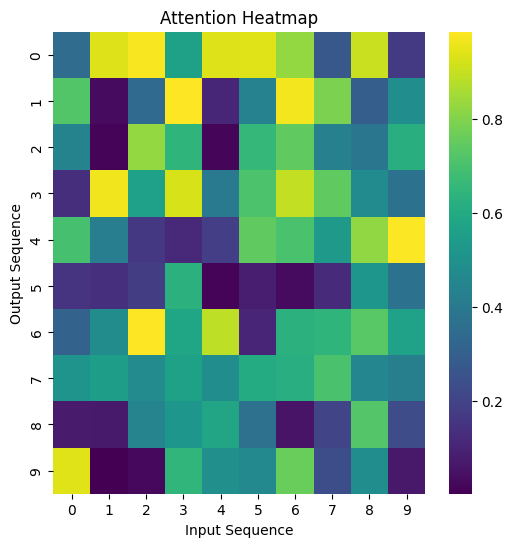

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Dummy attention weights
attention = np.random.rand(10,10)

plt.figure(figsize=(6,6))
sns.heatmap(attention, cmap='viridis')
plt.title("Attention Heatmap")
plt.xlabel("Input Sequence")
plt.ylabel("Output Sequence")
plt.show()

**Lab**- 7

In [ ]:
!pip install transformers datasets accelerate

from datasets import load_dataset
from transformers import (AutoTokenizer,
                          AutoModelForSequenceClassification,
                          TrainingArguments,
                          Trainer,
                          DataCollatorWithPadding)

# ✅ Load small subset (IMPORTANT)
dataset = load_dataset("imdb")

train_dataset = dataset["train"].shuffle(seed=42).select(range(2000))
test_dataset = dataset["test"].shuffle(seed=42).select(range(500))

# ✅ Use smaller tokenizer/model
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(example):
    return tokenizer(example["text"], truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

# ✅ Dynamic padding (saves RAM)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# ✅ Load lightweight model
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2
)

# ✅ Training settings (low RAM)
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    logging_steps=50,
    save_strategy="no",
    fp16=True  # if GPU available
)

# ✅ Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
)

trainer.train()

print("✅ Training Completed")

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
50,0.613159
100,0.464532
150,0.445057
200,0.438981
250,0.362747


✅ Training Completed


Lab-**8**


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

latent_dim = 2

# Encoder
encoder = tf.keras.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(latent_dim*2)
])

# Decoder
decoder = tf.keras.Sequential([
    layers.Dense(128, activation='relu'),
    layers.Dense(28*28, activation='sigmoid'),
    layers.Reshape((28,28))
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
from tensorflow.keras import layers

# Generator
generator = tf.keras.Sequential([
    layers.Dense(128, activation='relu', input_dim=100),
    layers.Dense(784, activation='sigmoid'),
    layers.Reshape((28,28))
])

# Discriminator
discriminator = tf.keras.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
!pip install torch-geometric

import torch
from torch_geometric.datasets import Planetoid

dataset = Planetoid(root='/tmp/Cora', name='Cora')

print(dataset[0])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 14.4 MB/s eta 0:00:00


Processing...


Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


Done!
